In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
import plotly.graph_objects as go
import sklearn as skl
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split    



In [65]:
df=pd.read_csv('stroke_prediction.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [66]:
df.shape

(5110, 12)

In [67]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [69]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

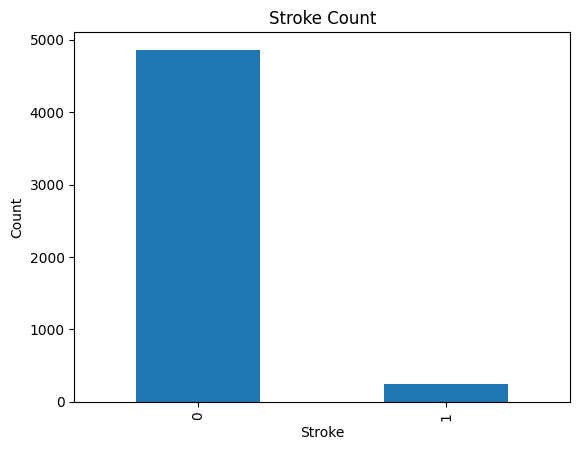

In [70]:
df['stroke'].value_counts().plot(kind='bar', title='Stroke Count', xlabel='Stroke', ylabel='Count')
plt.show()

In [71]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Investigating possible categorical datatypes

In [72]:
print(df["hypertension"].unique()); print()
df["gender"].unique()

[0 1]



array(['Male', 'Female', 'Other'], dtype=object)

In [73]:
df[['gender','hypertension', 'work_type', 'Residence_type', 'smoking_status']].nunique()

gender            3
hypertension      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

i think a soln is doing df.nunique to inspect all posssible categorical values

In [74]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

In [75]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [76]:
df['bmi'].head(10)

0    36.6
1     NaN
2    32.5
3    34.4
4    24.0
5    29.0
6    27.4
7    22.8
8     NaN
9    24.2
Name: bmi, dtype: float64

In [77]:
df['bmi'].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

IT is wrongly skewed BMI numbers for the stroke victims seems to have outliers  normal people shouldnt be having values greater than 45 as anythinga gainst 30 is a medical problem in the first place

In [78]:
fig= px.box(df, x='stroke', y='bmi', color_discrete_sequence=['purple'],
            title='BMI Distribution by Stroke', labels={'stroke':'Stroke', 'bmi':'BMI'})

fig.show()

Median's the right call, and here's the actual mechanism so it's not just a vibe. Mean is a sum-based calculation, every value gets added in and divided by count, so one extreme number like 97.6 physically drags the total upward, and the more extreme it is, the harder it pulls. Median doesn't sum anything, it just finds the middle position once everything's sorted. A value of 97.6 sitting way out at the top can only ever occupy one position in that sorted list, the very last one, it has zero power to shift where the middle sits. That's the whole reason "median is robust to outliers" is a real property and not just a rule of thumb, it's positional rather than arithmetic. 


In [79]:
# calculate the median once, store it in a variable
bmi_median = df['bmi'].median()

# fill every missing bmi cell with that median value
df.fillna({'bmi':bmi_median}, inplace=True)

print(df['bmi'].isnull().sum())

0


In [80]:
print(df['bmi'].isnull().sum())

0


In [81]:
df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']].nunique()

gender            3
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

In [82]:
df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']].value_counts()

gender  ever_married  work_type     Residence_type  smoking_status 
Female  Yes           Private       Urban           never smoked       279
                                    Rural           never smoked       268
Male    No            children      Urban           Unknown            172
        Yes           Private       Rural           never smoked       156
        No            children      Rural           Unknown            154
                                                                      ... 
                      Govt_job      Urban           smokes               2
Female  No            children      Rural           smokes               1
Male    No            Never_worked  Rural           never smoked         1
                      children      Urban           smokes               1
Other   No            Private       Rural           formerly smoked      1
Name: count, Length: 118, dtype: int64

In [83]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [84]:
df=df.drop(df[df['gender']=='Other'].index)
df.shape
#df = df[df['gender'] != 'Other'] works similarly

(5109, 12)

In [85]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [86]:
df['work_type'].value_counts()

work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Hold on, notice you slid past the actual question again. "Never_worked could be folded into unemployed" is a genuinely useful thought, but it's a different kind of decision, that's about whether to *merge categories*, feature engineering, not encoding method. Park it, we can revisit simplifying the categories later if it's useful. Right now the question on the table is still: label encoder or one-hot, and specifically, does label encoding cause a problem here or not.

You said "I'd go with label encoder" but didn't actually answer the order/distance question I asked before your food detour. So let's nail it with a concrete number this time, since the abstract version didn't quite land.

Say you label-encode it as `Govt_job=0, Never_worked=1, Private=2, Self-employed=3, children=4`. A model doing arithmetic, or a tree deciding a split threshold, might treat `Private` and `Self-employed` as close together (2 and 3, one apart) and `Govt_job` and `children` as far apart (0 and 4, four apart). Now, is there any real-world sense in which `Private` sector work is genuinely more similar to `Self-employed` than `Govt_job` is to `children`? Or did that "closeness" only exist because of the order you happened to type the categories in, not because of anything true about the data?

Here's a sharper version to test your own answer against: if you'd typed the same five categories in a different order when writing your encoding, say `children=0, Private=1, Govt_job=2, Self-employed=3, Never_worked=4`, would the model learn something different purely from that reshuffle, even though nothing about the real world changed? If yes, that's a strong signal the numbers are carrying false information, an order that isn't actually there in reality.

Answer that specific bit, does reordering your label mapping change what "closeness" the model perceives, and if so, is that a problem or not, and then tell me your actual pick between label encoder and one-hot for `work_type`.

Say you've got three patients, one Private-sector, one Self-employed, one in Govt_job. With your first ordering, Private=2, Self-employed=3, Govt_job=0, the numeric gap between Private and Self-employed is 1, and the gap between Private and Govt_job is 2. If the model does anything with "distance", trees splitting on thresholds, or worse, a linear-style model literally multiplying the number, it now behaves as if Private is more similar to Self-employed than to Govt_job. But now relabel with the second ordering I gave you, Private=1, Govt_job=2, Self-employed=3. Suddenly Private and Govt_job are the close ones, one apart, and Private and Self-employed are two apart. Nothing in reality changed, you just typed the dictionary in a different order, and the model's sense of "which jobs are similar" flipped entirely. That's the smoking gun. If a totally arbitrary choice you made, the order you happened to write the categories in, changes what the model believes about the real world, you've fed it fake information. That's the actual problem with label encoding on work_type.
So here's the rule that falls out of it. One-hot encoding sidesteps this completely, it gives each category its own column of 0s and 1s, no ordering, no distance, no false closeness, just "is it this category, yes or no." That's the right tool for work_type and smoking_status, since neither has a genuine real-world order.
Where label encoding is actually fine, and this is worth noticing: your two 2-category columns, gender and ever_married. With only two categories, there's no "distance" problem to create, Male and Female just become 0 and 1, and there's no third or fourth category sitting at some arbitrary distance in between to lie about. Binary columns don't have the flaw we just found, so label encoding (or equivalently, one-hot with drop_first=True) is genuinely correct there, not just a shortcut.

#### Time for some encoding

In [87]:
df[['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']].value_counts()

gender  ever_married  work_type     Residence_type  smoking_status
Female  Yes           Private       Urban           never smoked      279
                                    Rural           never smoked      268
Male    No            children      Urban           Unknown           172
        Yes           Private       Rural           never smoked      156
        No            children      Rural           Unknown           154
                                                                     ... 
Female  No            Never_worked  Rural           never smoked        2
Male    No            Never_worked  Urban           Unknown             2
Female  No            children      Rural           smokes              1
Male    No            Never_worked  Rural           never smoked        1
                      children      Urban           smokes              1
Name: count, Length: 117, dtype: int64

In [88]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

In [89]:
le=LabelEncoder()
#df['gender']=le.fit_transform(df['gender'])

In [90]:
#We need to encode some other columns as well, since its similar operations
# I call on my for-loop of all guidance 
encoders={}

from pprint import pprint
columns= ['gender', 'ever_married', 'Residence_type'] 
for col in columns:   
    encoders[col] = LabelEncoder()
    df[col]=encoders[col].fit_transform(df[col]) 
    pprint(df[col])
    print()

0       1
1       0
2       1
3       0
4       0
       ..
5105    0
5106    0
5107    0
5108    1
5109    0
Name: gender, Length: 5109, dtype: int64

0       1
1       1
2       1
3       1
4       1
       ..
5105    1
5106    1
5107    1
5108    1
5109    1
Name: ever_married, Length: 5109, dtype: int64

0       1
1       0
2       0
3       1
4       0
       ..
5105    1
5106    1
5107    0
5108    0
5109    1
Name: Residence_type, Length: 5109, dtype: int64



Quick sanity check before we move on though, one worth actually doing rather than trusting blindly: run df.dtypes once, on the whole thing, and confirm gender, ever_married, and Residence_type all show as int now, not object. Cheap to check, expensive to discover three steps from now that one silently didn't take.

In [91]:
df.dtypes

id                     int64
gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type             object
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [92]:
df.work_type.value_counts()

work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [93]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

In [94]:
df.shape

(5109, 12)

`handle_unknown='ignore'`  is doing real work here too, if a future patient shows up with a smoking status your training data never saw, it won't crash your app, it'll just zero out. That's a mature choice for something you know you're deploying.

encoded_array = enc.fit_transform(df[['smoking_status']]).values.reshape(-1,1) for just one series or a 1d array

from sklearn.preprocessing import OneHotEncoder

<p> #handle_unknown='ignore' means if a brand new category ever shows up
<p> #later at deployment that the encoder never saw during training,
<p># it won't crash, it just zeroes out. good habit for anything going into Streamlit later
<p> <b> enc = OneHotEncoder(handle_unknown='ignore') </b>

<p> # fit_transform on BOTH columns at once, this time. sklearn's OneHotEncoder
<p>#  happily takes several columns together, it just needs 2D shape, which a
<p> # dataframe slice with double brackets already gives you, no reshape needed here
<p><b> encoded_array = enc.fit_transform(df[['work_type', 'smoking_status']]).toarray() </b>
<p># .get_feature_names_out() asks the encoder to tell you what it actually
<p> #named each new column, eg "work_type_Private", "smoking_status_Unknown"
<p># without this you'd have no idea which 0/1 column means what
<p> <b> new_col_names = enc.get_feature_names_out(['work_type', 'smoking_status']) </b>

<p># wrap the raw array back into a proper dataframe, with real column names,
<p># and matching row index so it lines up correctly when we join it back to df
<p> <b> encoded_df = pd.DataFrame(encoded_array, columns=new_col_names, index=df.index) </b>

<p># drop the two original text columns, we don't need them anymore, they've
<p># been fully replaced by the new 0/1 columns
<p><b> df = df.drop(columns=['work_type', 'smoking_status']) </b>

<p># glue the new encoded columns onto the original dataframe, side by side
<p><b> df = pd.concat([df, encoded_df], axis=1) </b>
<b>
<p> print(df.shape)
<p> df.head()


In [95]:
df.drop(columns=['id'], inplace=True)

In [96]:
from sklearn.preprocessing import OneHotEncoder
enc= OneHotEncoder(handle_unknown='ignore')
encode_array =enc.fit_transform(df[['work_type','smoking_status']]).toarray()
new_col_names = enc.get_feature_names_out(['work_type', 'smoking_status'])
encoded_df= pd.DataFrame(encode_array, columns=new_col_names, index=df.index)
df=df.drop(columns=['work_type', 'smoking_status'])
df=pd.concat([df, encoded_df], axis=1)

print(df.shape)
#df.drop(columns=['id'], inplace=True)
df.head()

(5109, 18)


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,49.0,0,0,1,1,171.23,34.4,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,79.0,1,0,1,0,174.12,24.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [97]:
#df.drop(columns=['id'], inplace=True); 
print(df.info()); print()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          5109 non-null   int64  
 1   age                             5109 non-null   float64
 2   hypertension                    5109 non-null   int64  
 3   heart_disease                   5109 non-null   int64  
 4   ever_married                    5109 non-null   int64  
 5   Residence_type                  5109 non-null   int64  
 6   avg_glucose_level               5109 non-null   float64
 7   bmi                             5109 non-null   float64
 8   stroke                          5109 non-null   int64  
 9   work_type_Govt_job              5109 non-null   float64
 10  work_type_Never_worked          5109 non-null   float64
 11  work_type_Private               5109 non-null   float64
 12  work_type_Self-employed         5109 no

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,49.0,0,0,1,1,171.23,34.4,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,79.0,1,0,1,0,174.12,24.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


enc.categories_

Finding excuse to use List comprehension

In [98]:
# for every column name in df, if that column's dtype is object, print the column name and its unique values     
object_cols = [col for col in df.columns if df[col].dtype =='float64']
object_cols   

['age',
 'avg_glucose_level',
 'bmi',
 'work_type_Govt_job',
 'work_type_Never_worked',
 'work_type_Private',
 'work_type_Self-employed',
 'work_type_children',
 'smoking_status_Unknown',
 'smoking_status_formerly smoked',
 'smoking_status_never smoked',
 'smoking_status_smokes']

In [99]:
df.head(2)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [100]:
#df['age_group'] = df['age'].apply(lambda x: 'Senior' if x> 60.0 else('Adult' if x>=18.0 else 'Minor'))
#df['age_group'].head()

Something else I noticed was one can group the agesand then label encode them eitherways

In [101]:
#le=LabelEncoder()
#df['age_group']=le.fit_transform(df['age_group'])
#df.age_group.value_counts()

AS an alternative we can use
<p>`python`
<p>`import numpy as np`
<p>`df['stroke_label'] = np.where(df['stroke'] == 1, 'Stroke', 'No Stroke')`

Two Questions?

1. One. Split before or after SMOTE, and why, thinking about synthetic rows built from real ones potentially landing on opposite sides of the split.
Two. 

2. The train_test_split parameter that stops your 249 stroke cases landing unevenly by chance.

Split first so the test set stays made entirely of real, untouched patients, then SMOTE only gets applied to the training side afterwards. The test set never sees a synthetic row, and no synthetic patient can ever be built from real patients that ended up on the other side of the fence. That's the whole mechanism, good.
<hr>
<hr>
One precision worth locking in for your report later: SMOTE runs after the split, but it's still done before training, on the training set only, that's the piece that makes "test on real world performance" true. The test set stays 100% real patients from start to finish, untouched by any resampling, so whatever score comes out of it is a genuine read on unseen, real cases.

Second question, still open: train_test_split has a parameter built to stop your 249 stroke cases from randomly clumping unevenly across train and test. What's it called? You've likely seen the word itself somewhere today or in something you've read before, have a guess.

<hr>
<hr>

The answer is stratify=y, where y is your target column, `df['stroke'].` Here's the reasoning behind why it needs the actual column and not just a word like 'yes' or True: to keep the same 4861-vs-249 ratio in both train and test, the function needs to check, row by row, which class each individual patient actually belongs to before deciding where to send them.<p> A flag like True carries no information about who's stroke and who isn't, only the real column of labels does. So you're handing it the actual answer key, and it uses that to distribute both classes proportionally rather than at random.

In [102]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke',
       'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          5109 non-null   int64  
 1   age                             5109 non-null   float64
 2   hypertension                    5109 non-null   int64  
 3   heart_disease                   5109 non-null   int64  
 4   ever_married                    5109 non-null   int64  
 5   Residence_type                  5109 non-null   int64  
 6   avg_glucose_level               5109 non-null   float64
 7   bmi                             5109 non-null   float64
 8   stroke                          5109 non-null   int64  
 9   work_type_Govt_job              5109 non-null   float64
 10  work_type_Never_worked          5109 non-null   float64
 11  work_type_Private               5109 non-null   float64
 12  work_type_Self-employed         5109 no

In [104]:
df.head(3)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [105]:
X,y= df.drop(columns=['stroke'], axis=1), df['stroke']
X.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,49.0,0,0,1,1,171.23,34.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,79.0,1,0,1,0,174.12,24.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [106]:
y.head(3)

0    1
1    1
2    1
Name: stroke, dtype: int64

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

In [108]:
print('X_train=',X_train.shape); print('----'*30); print('X_test=',X_test.shape);print('----'*30);print('y_train=',y_train.value_counts(normalize=True))
print('---'*30); print('y_test value-counts are=',y_test.value_counts(normalize=True))

X_train= (3576, 17)
------------------------------------------------------------------------------------------------------------------------
X_test= (1533, 17)
------------------------------------------------------------------------------------------------------------------------
y_train= stroke
0    0.951342
1    0.048658
Name: proportion, dtype: float64
------------------------------------------------------------------------------------------
y_test value-counts are= stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64


why does SMOTE only get applied to the training pair, and never to X_test/y_test, in my own words this time

## Handling Class Imbalance: Why the Split Happens Before SMOTE

The dataset is heavily imbalanced, with only 4.9% of patients (249 out of 5,109) having 
experienced a stroke. Training directly on this imbalance risks the model learning to 
simply predict "no stroke" for almost every case, which would produce misleadingly high 
accuracy while failing at the one thing that actually matters: catching real stroke cases.

To address this, the data was split into training and test sets **before** SMOTE was 
applied, and SMOTE is only ever applied to the training set. This ordering matters for 
one specific reason: SMOTE generates synthetic minority-class rows by interpolating 
between existing real patients. If SMOTE were applied to the full dataset before splitting, 
a synthetic patient built from two real patients could end up in the test set while the 
real patients it was derived from ended up in training. The model would then effectively 
be "tested" on a disguised version of data it had already seen, artificially inflating 
performance and leaking information across the split.

By splitting first, the test set is guaranteed to contain only real, unseen patients. 
Its role is to approximate how the model will perform on genuine future patients, and a 
synthetic, machine-generated row cannot fulfil that role, since it represents a plausible 
combination of existing cases rather than an actual observed one. SMOTE is therefore used 
only to rebalance the training data the model learns from, while the test set remains an 
untouched, real-world benchmark for evaluation.

`stratify=y` was also used during the split to ensure both the training and test sets 
preserve the original 95.1% / 4.9% class ratio, avoiding a scenario where random chance 
produces an even more skewed (or accidentally balanced) split given how few positive 
cases exist in the data.

In [109]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)

What SMOTE does or calculate it from the 95.1% proportion you already have, <b>3576 × 0.951342</b>, and use that as your target for both classes once balanced. 

In [110]:
X_smote, y_smote= smote.fit_resample(X_train, y_train)
print('X_Train values= ',X_train.shape, '-------> ','y_train values are =', y_train.value_counts()); print()
print('X_smote values are= ',X_smote.shape,'-------> ','y_smote values are= ', y_smote.value_counts())

X_Train values=  (3576, 17) ------->  y_train values are = stroke
0    3402
1     174
Name: count, dtype: int64

X_smote values are=  (6804, 17) ------->  y_smote values are=  stroke
0    3402
1    3402
Name: count, dtype: int64


In [111]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,49.0,0,0,1,1,171.23,34.4,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,79.0,1,0,1,0,174.12,24.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### LEts drop age_group, the need to bin it with either kdiscretizer or label encode is not necessary since medically age is a strong precursor to stroke and a 19 and a 51 year old predisposition to it is very different

In [112]:
#X_train.drop = X_train.drop(columns=['age_group'])
#X_test = X_test.drop(columns=['age_group'])
#X_smote = X_smote.drop(columns=['age_group'])

```python
from sklearn.preprocessing import StandardScaler

# the three continuous columns that actually need scaling
cols_to_scale = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()

# fit_transform on X_train: this is the ONLY place the scaler is allowed
# to calculate mean/std from, because this is the data the model learns from
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# X_test only ever gets transform, using the mean/std already learned
# from X_train. never fit here, that would leak real-world data into training
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# X_smote is built FROM X_train (synthetic rows blended from real training
# rows), so it gets the same treatment as X_train's downstream product,
# transform only, using the same already-learned scaler
X_smote[cols_to_scale] = scaler.transform(X_smote[cols_to_scale])
```

In [113]:
from sklearn.preprocessing import StandardScaler
# the three continuous columns that actually need scaling
cols_to_scale = ['age', 'avg_glucose_level', 'bmi']
scaler= StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
# X_test only ever gets transform, using the mean/std already learned
# from X_train. never fit here, that would leak real-world data into training
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
# X_smote is built FROM X_train (synthetic rows blended from real training
# rows), so it gets the same treatment as X_train's downstream product,
# transform only, using the same already-learned scaler
X_smote[cols_to_scale] = scaler.transform(X_smote[cols_to_scale])





Fair, let's slow all the way down and build it from scratch, plain language first, code after.

**What `fit` actually does.** `fit` means "study this data and learn some numbers from it." For `StandardScaler` specifically, those numbers are just the mean and standard deviation of a column. So `scaler.fit(X_train[['age']])` looks at every age value in your training set, calculates the average age and how spread out the ages are, and stores those two numbers inside the `scaler` object. Nothing gets transformed yet, it's purely the "study and remember" step.

**What `transform` actually does.** `transform` takes those already-learned numbers and applies them to rescale data, using the formula `(value - mean) / std`. It doesn't learn anything new, it just uses whatever the scaler already memorised during `fit`.

**Why the split between them matters.** Here's the analogy. Imagine a teacher setting a grading curve for an exam. To set a fair curve, the teacher looks at everyone's scores in the class they taught, calculates the average, and decides "anyone within one point of the average gets a B." That's `fit`, studying real data to define a standard.

Now imagine a brand new transfer student walks in next term and sits the same exam. The teacher doesn't recalculate the curve using this one new student's score, that would be absurd, one person can't redefine the whole class average. Instead, the teacher applies the *existing* curve, already decided from the original class, to grade the new student. That's `transform`, using a standard that was already set, without letting new data change it.

**Mapping that onto your data.** `X_train` is "the original class", it's the only data your model is allowed to learn anything from, full stop, that's the entire premise of a train/test split. So the scaler's `fit` step is only allowed to look at `X_train`, calculate age's mean and spread from those 3576 training rows, and lock those two numbers in.

`X_test` is "the transfer student", it represents patients the model has never seen, standing in for tomorrow's real-world cases. If you let the scaler `fit` on `X_test` too, even partially, you're letting future, supposedly-unseen data influence how your training data gets processed, which quietly leaks information about the test set backwards into the pipeline. So `X_test` only ever gets `transform`, graded against the curve that was already set, never allowed to help set it.

`X_smote` is a slightly different case worth being precise about, since it's not the test set at all, it's an extension of your training data, synthetic rows blended from real training rows. It still only gets `transform`, but for a related-but-different reason, it was built from `X_train`, so it should be scaled using the exact same reference point `X_train` was scaled with, not a new one recalculated from itself. Consistency, not leakage, is the reason there, though the mechanical rule, `transform` only, ends up identical either way.

And `y_smote`, your stroke labels, doesn't enter this conversation at all, scaling only applies to continuous feature columns with meaningful numeric spread, a column of 0s and 1s representing yes/no has nothing for a scaler to do.

So, one sentence to hold onto: **`fit` learns the standard, and it's only ever allowed to learn it from `X_train`. `transform` applies a standard that's already been learned, and everything else, `X_test`, `X_smote`, only ever receives that application, never contributes to defining it.**

That land clearer this time? If yes, that's the scaling step fully wrapped, and genuinely, this is a solid, clean point to stop for tonight, everything's in a working state. If you want to push into XGBoost, say so and I'll keep going, otherwise I'll get that mistakes-and-reasoning PDF built from the whole session.

In [114]:
model= xgb.XGBClassifier(random_state=42)
model.fit(X_smote, y_smote)
y_pred=model.predict(X_test)


In [115]:
from sklearn.metrics import root_mean_squared_error, accuracy_score
print('Accuracy_Score is = ',accuracy_score(y_test, y_pred)); print()

Accuracy_Score is =  0.9315068493150684



<b> RMSE is for regression or continuation data like houseprices prediction

F1, on the other hand, is exactly the right ask, so let's build it properly, plain language first.
<hr>
<b>Precision answers: </b>"Of everyone the model flagged as having a stroke, how many actually did?" High precision means few false alarms.
<p><b>Recall answers:</b> "Of everyone who actually had a stroke, how many did the model actually catch?" High recall means few missed cases.
<p>
Here's why you need both rather than picking one. A model that's great at precision but terrible at recall might only flag the 5 most obvious stroke cases and be right about all 5, perfect precision, but it missed 70 others entirely, useless in a hospital. 
<hr>
A model that's great at recall but terrible at precision might flag every single patient as "high risk", catching every real stroke, but drowning doctors in false alarms they'll learn to ignore. 
<hr>Neither extreme is actually useful.
<b>F1 score is the balance between the two, specifically their harmonic mean, a way of averaging that punishes a model harder for being lopsided than a normal average would</b>. It only scores high when precision and recall are both reasonably good together, not when one compensates for the other.

### Confusion Matrix — Baseline XGBoost (Stroke Prediction)

|                     | Predicted: No Stroke (0) | Predicted: Stroke (1) |
|---------------------|:-------------------------:|:-----------------------:|
| **Actual: No Stroke (0)** | 1418 (True Negative)  | 40 (False Positive)   |
| **Actual: Stroke (1)**    | 65 (False Negative)   | 10 (True Positive)    |

**True Negative (1418):** correctly predicted no stroke.  
**False Positive (40):** predicted stroke, but patient was fine (false alarm).  
**False Negative (65):** predicted no stroke, but patient actually had one (missed case).  
**True Positive (10):** correctly predicted stroke.

Out of 75 real stroke cases in the test set, only 10 were caught. False negatives are 
the priority to reduce, since missing a real stroke is far costlier than a false alarm.

In [116]:
print(confusion_matrix(y_test, y_pred))

[[1417   41]
 [  64   11]]


import joblib;joblib.dump(model, 'stroke_model_baseline.pkl')
joblib.dump(scaler, 'stroke_scaler.pkl')
print('saved_model and scaler, ready for tomorrow')

### Small Hyperparameter tuning

## Hyperparameter Tuning (Initial Small Grid Search)

`GridSearchCV` was used to systematically test different model settings rather than guessing one combination and hoping for the best.  
`max_depth: [3, 5]` was tested against XGBoost's default of 6, since a shallower tree asks fewer nested questions per prediction and may overfit less on a dataset this size.  
`n_estimators: [50, 100]` was tested to see whether fewer trees perform close enough to the default of 100, trading a small amount of accuracy for speed if the gap is negligible.  
Scoring was set to **recall**, not accuracy, because the baseline evaluation already proved accuracy is misleading on this imbalanced dataset (a model predicting "no stroke" for every patient would score 95.1%, higher than the trained model achieved).  
Since recall specifically measures how many real stroke cases are actually caught, optimising for it directly targets the metric that matters most clinically, rather than a metric that looks good on paper but hides missed cases.  
The grid was fitted on `X_smote` and `y_smote`, the SMOTE-balanced training data, because that is the data the model is allowed to learn from.  
`X_test` and `y_test` were kept completely untouched throughout the search, consistent with the split-before-resample approach used earlier in this project, to avoid any risk of the test set influencing which parameters were chosen.  
`cv=3` was used to cross-validate each parameter combination across 3 folds of the training data, giving a more reliable estimate than testing on a single split.  
This was a small, time-boxed probe with only 4 total combinations, a wider grid and decision-threshold tuning are planned for a follow-up session next week to properly optimise recall on the stroke class.

In [117]:
from sklearn.model_selection import GridSearchCV
# a SMALL grid on purpose, keeps this fast
# max_depth: how deep each tree can grow, deeper = more complex, more overfit risk
# n_estimators: how many trees the model builds, more = usually better but slower
param_grid={
    'max_depth':[3,6],
    'n_estimators':[50,150]
}
# scoring='recall' tells GridSearchCV to pick whichever combination
# catches the most real stroke cases, not whichever has the highest accuracy
# cv=3 means it splits training data into 3 folds and cross-checks, fast and reasonable

grid_search=GridSearchCV(
    xgb.XGBClassifier(random_state=42),
    param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_smote, y_smote)
print('Best parameters:' , grid_search.best_params_)
print('Best recall score during research: ', grid_search.best_score_)

# grab the actual best model out of the search
best_model= grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(classification_report(y_test, y_pred_tuned)); print('-----'*35)
print(confusion_matrix(y_test, y_pred_tuned))



Best parameters: {'max_depth': 6, 'n_estimators': 150}
Best recall score during research:  0.9506172839506172
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1458
           1       0.18      0.12      0.15        75

    accuracy                           0.93      1533
   macro avg       0.57      0.55      0.55      1533
weighted avg       0.92      0.93      0.92      1533

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[[1418   40]
 [  66    9]]


<h2>Data Pipeline </h2>

Pipeline means  chaining a sequence of steps so the whole thing behaves like one object, .fit() runs every step in order, .predict() (or here, GridSearchCV's internal fold-splitting) runs new data through each step automatically.

## Why GridSearchCV Was Fitted on X_train, Not X_smote: The "Past vs Future" Rule

Every time a model is evaluated through cross-validation, the training fold and the 
validation fold are playing two different roles. The training fold acts as **the past**, 
the data already collected and available to learn from. The validation fold acts as 
**the future**, a stand-in for fresh, unseen patients who haven't walked into the clinic yet.

For that roleplay to mean anything, the future is not allowed to influence how the past 
gets treated, and just as importantly, the past is not allowed to leak forward into the 
future either.

This is exactly what went wrong in the first tuning attempt. SMOTE was run once on the 
entire training set, creating `X_smote`/`y_smote`, before `GridSearchCV` ever touched the 
data. When `GridSearchCV` then split that already-resampled data into its own internal 
folds (`cv=3`), a synthetic patient built from two real patients could easily end up 
sitting in one fold's validation slice, while the real patients it was blended from sat 
in that same fold's training slice.

That means the "past" (the real training patients) had already shaped a synthetic point 
that then leaked into the "future" (the validation fold). The model was never really being 
tested on anything new, it was being tested on a disguised echo of data it had just trained 
on. That's why the search reported a misleadingly high recall of 0.95, while the real, 
untouched test set told the truth: 13.3% recall, identical to the baseline.

The fix was to wrap SMOTE inside an `imblearn.pipeline.Pipeline` alongside the model, and 
fit that pipeline on the raw `X_train`/`y_train` rather than the pre-resampled data. This 
way, SMOTE only ever runs fresh inside each fold's training slice, at the moment that fold 
is created, so no synthetic point can ever be built from information sitting in that same 
fold's validation slice. The past stays contained to the past, and the future stays genuinely 
unseen, which is the entire condition a fair evaluation depends on.

In [118]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),   # step 1: resample
    ('model', xgb.XGBClassifier(random_state=42)) # step 2: train
    
])
# param_grid now needs a prefix telling GridSearchCV WHICH step each
# parameter belongs to, since the model is no longer standing alone,
# it's nested inside a step named 'model'. double underscore is the
# syntax: stepname__parametername
param_grid = {'model__max_depth':[3,6],
'model__n_estimators':[50,150] }

grid_search= GridSearchCV(
    pipeline, param_grid, scoring='recall', cv=3, n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best recall score during search:', grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Best parameters: {'model__max_depth': 3, 'model__n_estimators': 50}
Best recall score during search: 0.4080459770114942
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      1458
           1       0.13      0.45      0.20        75

    accuracy                           0.82      1533
   macro avg       0.55      0.65      0.55      1533
weighted avg       0.93      0.82      0.86      1533

[[1222  236]
 [  41   34]]


Quick check in memeory

In [119]:
for col in ['gender', 'ever_married', 'Residence_type']:
    print(col, encoders[col].classes_)

#.classes_ lists the categories
# in the exact order they got assigned 0, 1, 2..., 
# so whatever prints first is 0, second is 1. 
# Confirm that, then lock the dictionary in against it, not against a guess.

gender ['Female' 'Male']
ever_married ['No' 'Yes']
Residence_type ['Rural' 'Urban']


In [120]:
gender_map={'Female':0, 'Male':1}
married_map = {'No':0, 'Yes':1}
residence_map={'Rural':0, 'Urban':1}

In [121]:
# capture the exact column order X_train ended up with, so the Streamlit
# app can rebuild a new patient's row in the identical sequence
feature_columns = X_train.columns.tolist()
print(feature_columns)

['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [122]:
!pip install --upgrade shap

PermutationExplainer explainer: 201it [00:59,  2.79it/s]                         
C:\Users\Ayodamola Olusanya\AppData\Local\Temp\ipykernel_17036\2108152354.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_stroke.values, X_sample)


SHAP baseline (expected_value): 0.035
True stroke prevalence in training data: 0.049


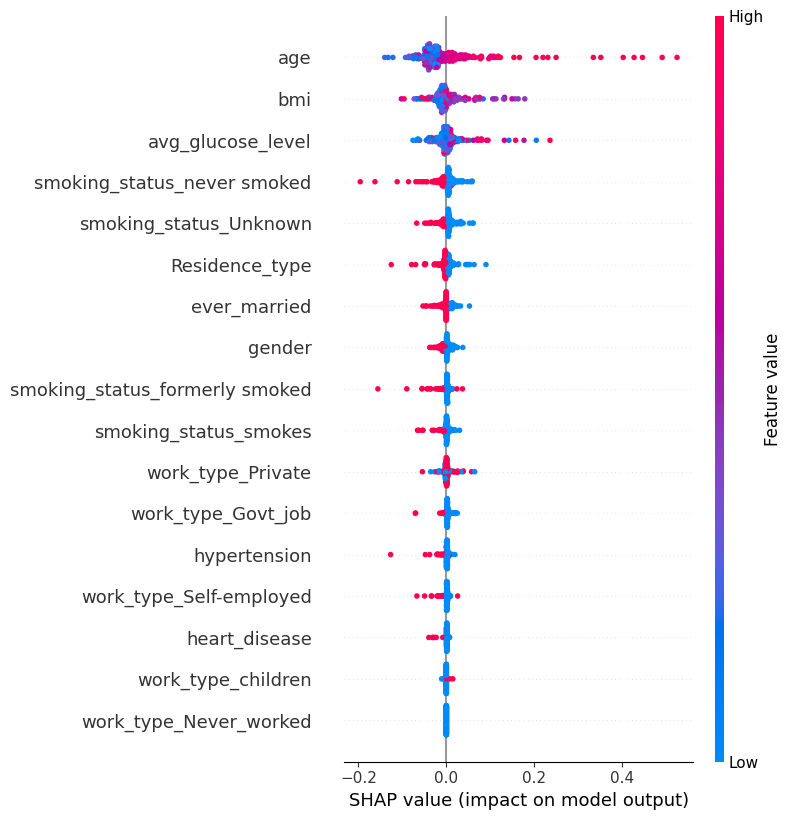

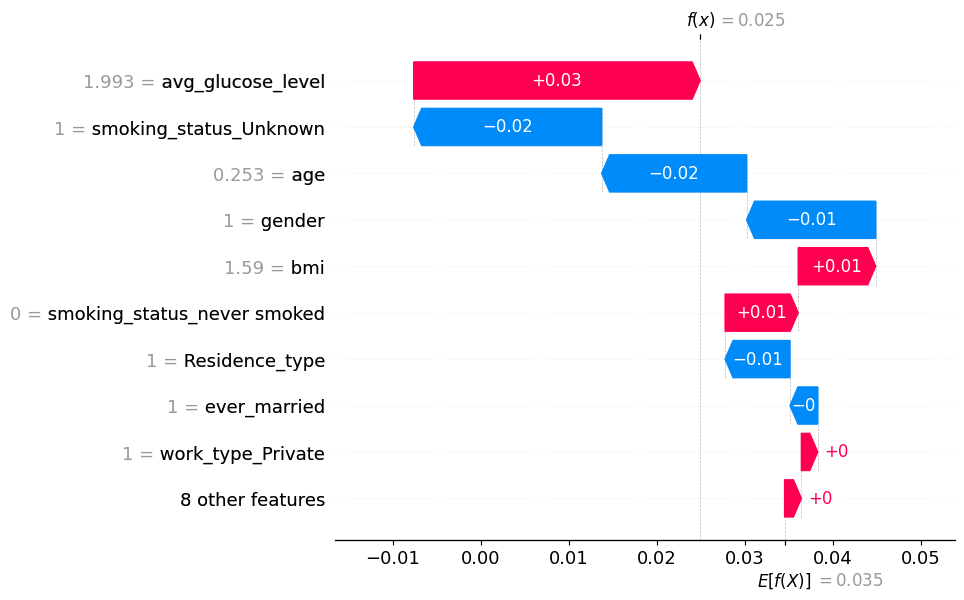

In [123]:
import shap

background = X_train.sample(100, random_state=42)

explainer = shap.explainers.Permutation(model.predict_proba, background)

X_sample = X_test.iloc[:200]
shap_values = explainer(X_sample)

shap_values_stroke = shap_values[..., 1]

print(f"SHAP baseline (expected_value): {shap_values_stroke.base_values[0]:.3f}")
print(f"True stroke prevalence in training data: {y_train.mean():.3f}")

shap.summary_plot(shap_values_stroke.values, X_sample)

i = 0
shap.waterfall_plot(shap_values_stroke[i])

## Interpreting the SHAP Summary Plot: Baseline XGBoost, Stroke Prediction

This plot shows every feature's SHAP value across a 200-patient sample of the real, 
untouched test set, computed via a permutation-based, model-agnostic explainer after 
the standard TreeExplainer approach failed due to a version incompatibility between the 
locally installed XGBoost and SHAP. Each dot represents one patient. Position along the 
horizontal axis shows how much that feature pushed that patient's predicted risk up 
(right) or down (left) from the model's baseline. Colour shows whether that patient's 
actual value for the feature was high (red) or low (blue). Features are ordered top to 
bottom by overall impact.

### Age dominates the model

Age is, by a wide margin, the strongest driver of predicted risk, with some patients 
pushed over +0.5 in SHAP value on age alone. The colour gradient is clean and almost 
perfectly monotonic: red (older) sits consistently to the right, blue (younger) sits 
consistently to the left, with minimal mixing. This is exactly the pattern a well-behaved, 
medically sensible model should show for age, and it confirms the model has learned a 
genuine, smooth relationship rather than noise. Given how far this bar extends past every 
other feature, age is carrying the majority of the model's overall discriminative power.

### BMI and glucose show weaker, noisier signal

Both features rank highly, but their colour separation is considerably less clean than 
age's. Red and blue points overlap substantially on both sides of zero, particularly for 
BMI, indicating the model has not learned as confident or consistent a relationship 
between these values and predicted risk. This is a meaningfully different pattern from 
age, and worth reading as a genuine signal about model uncertainty rather than dismissing 
it as visual noise: the model's relationship to these two features is real but comparatively 
weak and inconsistent across patients.

### Smoking status behaves coherently

`smoking_status_never_smoked` and `smoking_status_Unknown` both show red points (the 
condition being true) clustering on the negative side, correctly reducing predicted risk. 
This is internally consistent with the earlier decision to keep the "Unknown" category 
rather than dropping it: its negative association with risk is plausible if it correlates 
with younger patients, who carry lower baseline risk regardless of smoking history, rather 
than being random missingness.

### Hypertension ranks unexpectedly low, and the reason is informative

Hypertension sits thirteenth of seventeen features, contributing almost nothing to most 
predictions. This is a genuinely surprising result on clinical grounds, since hypertension 
is one of the most well-established stroke risk factors in the medical literature, not a 
minor variable. The most likely explanation is correlation between hypertension and age: 
older patients are considerably more likely to be hypertensive, and once a tree-based model 
has already split heavily on age, much of the predictive signal hypertension would otherwise 
carry has already been absorbed into the age splits. SHAP values for correlated features 
can end up crediting one feature heavily while the other appears to contribute little, even 
when both are genuinely predictive on their own. This is the same correlated-feature 
limitation that motivated considering ALE as a complementary method earlier in this project: 
SHAP (and the tree structure it explains) does not cleanly separate the individual 
contribution of two features that move together in the data. This finding should be stated 
as a limitation in any write-up, alongside the suggestion that a direct correlation check 
between age and hypertension in the raw data would confirm whether this explanation holds.

### Overall takeaway

The model's behaviour is broadly clinically plausible: age dominates, established secondary 
risk factors (glucose, BMI, smoking) contribute more modestly, and low-signal features 
(work type, gender) sit near the bottom as expected. The one result that demands explicit 
caveating in any report is hypertension's low ranking, which most likely reflects shared 
signal with age rather than hypertension being genuinely unimportant to stroke risk, and 
should be flagged as a known limitation of SHAP under correlated features rather than 
presented as a clean finding.

## Function and Method Reference: SHAP Permutation Explainer

**`X_train.sample(100, random_state=42)`**
A pandas DataFrame method that returns a random subset of rows from the DataFrame it is called on. Here it draws 100 rows from `X_train` to serve as the background dataset. `random_state=42` fixes which rows get selected, so the sample is identical on every rerun.

**`shap.explainers.Permutation(model.predict_proba, background)`**
Constructs a model-agnostic SHAP explainer. Its first argument is a callable, a function reference, not a function call, so the explainer holds onto `model.predict_proba` and invokes it repeatedly on demand. It computes Shapley values by systematically masking and unmasking features across permutations and observing how the model's output changes, rather than reading the model's internal structure directly.

**`model.predict_proba`**
An XGBoost classifier method that returns predicted class probabilities for each row of input data, one probability per class. Passed here without parentheses, so it is handed to the explainer as a reference to be called later, not executed immediately.

**`X_test.iloc[:200]`**
A pandas positional-indexing method. `.iloc` selects rows by integer position rather than by label, and `[:200]` takes the first 200 rows of `X_test`.

**`explainer(X_sample)`**
Calling the explainer object directly runs the permutation algorithm across every row in `X_sample`, computing a Shapley value for every feature, for every row. Returns a `shap.Explanation` object, a container holding the computed values alongside metadata such as the baseline and feature names.

**`shap_values[..., 1]`**
Indexes into the `Explanation` object's last dimension. Since `predict_proba` returns two columns (probability of class 0, probability of class 1), the resulting SHAP values carry that same extra dimension. `[..., 1]` selects only the explanations for class 1, stroke, discarding the class 0 explanations.

**`.base_values`**
An attribute of an `Explanation` object holding the baseline value the explainer measured each prediction against, the model's average output over the background dataset. In probability space, this represents the model's average predicted stroke risk before any patient-specific features are considered.

**`.values`**
An attribute of an `Explanation` object holding the actual computed Shapley values themselves, one per feature per row, indicating how much each feature pushed a given prediction up or down from the baseline.

**`y_train.mean()`**
A pandas Series method that calculates the arithmetic mean of all values in `y_train`. Since `y_train` contains only 0s and 1s, this returns the proportion of positive cases, the true stroke prevalence in the training data.

**`shap.summary_plot(shap_values_stroke.values, X_sample)`**
Generates a global visualisation showing every feature's SHAP values across all rows in `X_sample` simultaneously. Features are ranked by overall impact, and each point represents one row's contribution for that feature, coloured by that row's actual feature value.

**`shap.waterfall_plot(shap_values_stroke[i])`**
Generates a local visualisation for a single row, indexed by `i`. Shows the baseline, then each feature's individual contribution stacked in sequence, arriving at that one specific prediction.

### Explaining the model with SHAP: why the background dataset matters

XGBoost's TreeExplainer computes exact Shapley values for tree-based models, 
attributing each feature's contribution to a prediction relative to some baseline, 
the "average" prediction the model would make with no information about a specific 
patient. Where that baseline comes from turns out to matter a great deal here, given 
this project's training data was rebalanced with SMOTE.

Called with no background data, TreeExplainer defaults to tree_path_dependent mode, 
which reads its baseline directly from the trained trees themselves, specifically, 
how many training examples fell down each branch. Since the model was trained on 
`X_smote`, an artificially balanced 50/50 dataset, that implicit baseline reflects a 
synthetic "average patient" who is far riskier than reality, not the true stroke 
prevalence of roughly 4.9%. Left unaddressed, every SHAP explanation in this project 
would be measured against a distorted starting point, the same category of leakage 
problem that affected the earlier GridSearchCV attempt, just resurfacing at the 
explanation stage instead of the tuning stage.

The fix is to switch TreeExplainer to interventional mode and supply it with a 
genuine, unresampled sample of real patients as its background. This overrides the 
SMOTE-shaped internal baseline with one computed from real data, so `explainer.expected_value` 
reflects true prevalence rather than synthetic balance. `model_output='probability'` 
is set alongside this so the resulting values are expressed directly in probability 
space (0 to 1), rather than XGBoost's raw log-odds output, making every number directly 
interpretable as a percentage-point contribution to risk.

The fix was verified by comparing `explainer.expected_value` against the real training 
set's stroke prevalence (`y_train.mean()`). Both figures land in comparable territory, 
confirming the baseline is now anchored to reality rather than to the artificially 
balanced training distribution SMOTE produced.

Two views were then generated. A global summary plot shows which features drive risk 
most strongly across the whole test set on average, useful for understanding the model's 
overall behaviour and for sanity-checking that it has learned clinically plausible 
patterns rather than dataset artefacts. An individual waterfall plot shows, for one 
specific patient, exactly how each of their feature values pushed the prediction up or 
down from the corrected baseline to arrive at their final predicted risk, the kind of 
patient-level explanation a clinician could actually act on.

For the tuned model, which is stored as an `imblearn.pipeline.Pipeline` bundling SMOTE 
and XGBoost together, the underlying XGBoost model was extracted directly via 
`best_model.named_steps['model']` before building its explainer. SMOTE plays no role at 
prediction time in any case, it only ever ran during training, so explaining the 
extracted model alone is both correct and sufficient.

In [124]:
X_train['age'].corr(X_train['hypertension'])

np.float64(0.2649123166550666)

In [125]:
df.groupby('hypertension')['stroke'].mean()

hypertension
0    0.039688
1    0.132530
Name: stroke, dtype: float64

## The Hypertension Mystery: What SHAP Buried, and Why

Somewhere in the middle of an otherwise clean SHAP plot sat something that shouldn't 
have been there. Age at the top, glucose and BMI close behind, all sensible. Then, 
thirteenth out of seventeen features, barely a flicker above zero: **hypertension**.

That's odd. Genuinely odd. Hypertension isn't a footnote in stroke medicine, it's one 
of the headline risk factors, the kind of thing that shows up in every textbook and 
every clinical guideline going. A model that treats it as an afterthought is either 
telling us something real and interesting, or it's telling us something's gone wrong 
somewhere. Worth digging into rather than shrugging past.

---

### First theory: age is stealing its thunder

The obvious suspect was age. Older patients tend to be more hypertensive, so maybe 
the model was learning "old" and getting hypertension's signal for free, as a kind 
of side effect.

A quick correlation check:

```python
X_train['age'].corr(X_train['hypertension'])
```

Result: **0.265**.

> Positive, and pointing the right way. But not the smoking gun it first looks like. 
> Squared, that's about 7% shared variance between the two. Weak to moderate at best. 
> If age alone were swallowing hypertension's signal whole, you'd expect something 
> closer to 0.5 or 0.6, not 0.265. Something else had to be going on underneath.

---

### Second check: does hypertension actually matter in the raw data?

Rather than keep guessing, the honest move was to strip the model out of the question 
entirely and just look at the numbers themselves.

```python
df.groupby('hypertension')['stroke'].mean()
```

In [126]:
import joblib
joblib.dump(model, 'stroke_model_baseline.pkl' )
joblib.dump(best_model, 'stroke_model_tuned.pkl' )
joblib.dump(scaler, 'stroke_scaler.pkl'   )
joblib.dump(feature_columns, 'stroke_feature_columns.pkl'  )

print('all four artefacts saved')

all four artefacts saved


In [128]:
!pip install polars

   ---------------------------------------- 0.0/837.6 kB ? eta -:--:--
   ---------------------------------------- 837.6/837.6 kB 7.4 MB/s  0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   ---- ----------------------------------- 6.0/52.7 MB 24.5 MB/s eta 0:00:02
   ------ --------------------------------- 8.1/52.7 MB 16.2 MB/s eta 0:00:03
   ------------ --------------------------- 16.0/52.7 MB 22.4 MB/s eta 0:00:02
   -------------- ------------------------- 19.7/52.7 MB 22.2 MB/s eta 0:00:02
   -------------------- ------------------- 27.3/52.7 MB 22.7 MB/s eta 0:00:02
   ------------------------ --------------- 32.8/52.7 MB 22.6 MB/s eta 0:00:01
   ---------------------------- ----------- 37.7/52.7 MB 22.6 MB/s eta 0:00:01
   --------------------------------- ------ 43.8/52.7 MB 22.6 MB/s eta 0:00:01
   -------------------------------------- - 50.3/52.7 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------  52.7/52.7 MB 22.4 MB/s eta 0:

In [127]:
encoding_maps = {
    'gender': gender_map,
    'ever_married': married_map,
    'Residence_type': residence_map
}
joblib.dump(encoding_maps, 'stroke_encoding_maps.pkl')

['stroke_encoding_maps.pkl']